In [1]:
import numpy as np
import pandas as pd
from sklearn import feature_extraction
import os, nltk, re, string, sklearn
pd.set_option('display.max_rows', 100)
base_dir = os.getcwd()
print(base_dir)
data = pd.read_csv('dataset.csv', usecols=['file', 'abstract'])

/Users/antique/Documents/GitHub/Sites/so-papers-simillarity


In [2]:
data = data[~data['abstract'].isna()].reset_index(drop=True)
data.head()

,file,abstract
0,Timur_Bachschi__Aniko_Hannak__Florian_Lemmeric...,Online knowledge platforms such as Stack Overf...
1,Sebastian_Baltes__Christoph_Treude__and_Martin...,Software engineering is knowledge-intensive an...
2,Sebastian_Baltes_and_Christoph_Treude__Code_Du...,Despite the unarguable importance of Stack Ove...
3,Sebastian_Baltes_and_Markus_Wagner__An_Annotat...,"To improve software engineering, software repo..."
4,Sengupta__S______Haythornthwaite__C__Learning_...,Stack Overflow (SO) has become a primary sourc...


In [14]:
# Strip punctuation
texts = data['abstract']
table = str.maketrans('', '', string.punctuation)
texts = [text.translate(table) for text in texts]
# removing all numbers to'num' 
texts = [re.sub(r'\d+', '', text) for text in texts]
#stopwords
stopwords = set(nltk.corpus.stopwords.words('english') + ['reuter', '\x03'])
texts = [[word for word in text.split() if word not in stopwords] for text in texts]
#flat_list = [item for sublist in l for item in sublist]
merged = []
for l in texts:
    merged += l


texts = " ".join(merged)
print(texts)

Online knowledge platforms Stack Overflow Wikipedia rely large diverse contributor community Despite efforts facilitate onboarding new users relatively users become core contributors suggesting existence barriers hurdles hinder full involvement community This paper investigates issues Stack Overflow widely popular question answer community computer programming We document evidence “leaky pipeline” specifically many active users platform never post answer Using starting point investigate potential factors linked transition new contributors asking questions posting answers We find user’s individual features tenure gender geographic location well features subcommunity active size prevalence negative social feedback significant relationship likelihood post answers By measuring modeling relationships paper presents first look challenges obstacles user promotion along pipeline contributions online communities Software engineering knowledgeintensive requires software developers continually se

### Word cloud

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=1024, height=768, colormap="Blues").generate(texts)

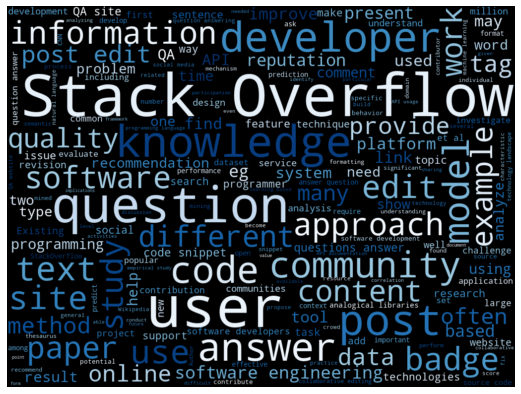

In [38]:
fig = plt.figure()
fig.set_size_inches(25, 7)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.margins(x=0, y=0)
plt.show()

### Paper data chart

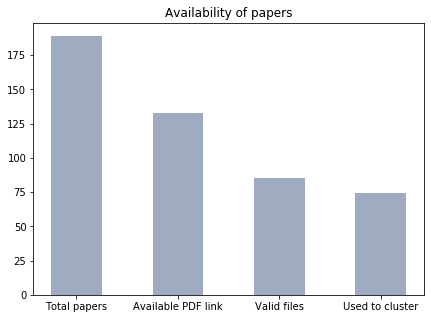

In [54]:
data = {'Total papers':189, 'Available PDF link':133, 'Valid files':85, 'Used to cluster':74}
labels = list(data.keys())
numbers = list(data.values())

fig = plt.figure(figsize = (7, 5)) 
plt.bar(labels, numbers, color ='#9FABC0', width = 0.5) 
plt.title('Availability of papers')
plt.show()